# Fuzzy Air Conditioner Controller

**Name** Tizita Girma
**MSIT5205 - Advanced Artificial Intelligence - Assignment II (Track C: Fuzzy Expert System)**

A Mamdani-type fuzzy logic controller, implemented **from scratch** (no external fuzzy-logic
library), that decides an air conditioner's **fan speed** and **cooling power** from two crisp
sensor readings: **room temperature** and **relative humidity**.

This notebook is a self-contained, runnable version of the original project (originally organized
as separate `.py` modules: `fuzzy/membership.py`, `fuzzy/fuzzy_system.py`, `test_cases.py`,
`visualize.py`, `gui.py`). Every section below can be run top-to-bottom.

**Contents**
1. Setup
2. Membership functions
3. Linguistic variables & rule base
4. The Mamdani inference engine
5. Single-inference demo & explanation
6. Test-case battery
7. Visualizations (membership functions, control surface, worked example)
8. Interactive widget demo (replaces the Tkinter GUI)
9. Unit tests


## 1. Setup

In [2]:
import math
import time
import csv
import os
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 2. Membership Functions

Fuzzy membership function primitives implemented from first principles. Each function takes a
crisp input `x` and shape parameters, and returns a membership degree in `[0, 1]`.

- **Trapezoidal** functions are used for the outer/extreme linguistic terms (`cold`, `hot`,
  `dry`, `humid`, `low`, `high`) so that extreme readings saturate at full membership.
- **Triangular** functions are used for the middle terms (`warm`, `normal`, `medium`) to give a
  smooth, symmetric peak.


In [3]:
def triangular(x: float, a: float, b: float, c: float) -> float:
    """Triangular membership function.

    Rises linearly from 0 at `a` to 1 at `b`, then falls linearly
    from 1 at `b` to 0 at `c`.  Requires a <= b <= c.
    """
    if a == b == c:
        return 1.0 if x == a else 0.0
    if x == b:
        return 1.0
    if x < a or x > c:
        return 0.0
    if a <= x < b:
        return (x - a) / (b - a) if b != a else 1.0
    # b < x <= c
    return (c - x) / (c - b) if c != b else 1.0


def trapezoidal(x: float, a: float, b: float, c: float, d: float) -> float:
    """Trapezoidal membership function.

    Rises linearly from 0 at `a` to 1 at `b`, stays at 1 between
    `b` and `c`, then falls linearly from 1 at `c` to 0 at `d`.
    Requires a <= b <= c <= d.
    """
    if b <= x <= c:
        return 1.0
    if x < a or x > d:
        return 0.0
    if a <= x < b:
        return (x - a) / (b - a) if b != a else 1.0
    # c < x <= d
    return (d - x) / (d - c) if d != c else 1.0


def clip(value: float, lo: float = 0.0, hi: float = 1.0) -> float:
    """Clamp a value into [lo, hi]."""
    return max(lo, min(hi, value))

# quick sanity check
print("triangular(50, 25, 50, 75) =", triangular(50, 25, 50, 75))   # peak -> 1.0
print("trapezoidal(10, 10, 10, 18, 22) =", trapezoidal(10, 10, 10, 18, 22))  # edge plateau -> 1.0


triangular(50, 25, 50, 75) = 1.0
trapezoidal(10, 10, 10, 18, 22) = 1.0


## 3. Linguistic Variables & Rule Base

**Inputs**
- Temperature: universe `[10, 40]` degC, terms `{cold, warm, hot}`
- Humidity: universe `[0, 100]` %, terms `{dry, normal, humid}`

**Outputs**
- Fan Speed: universe `[0, 100]` %, terms `{low, medium, high}`
- Cooling Power: universe `[0, 100]` %, terms `{low, medium, high}`

**Rule base:** 9 rules covering the full 3x3 Temperature x Humidity grid.


In [4]:
MembershipFn = Callable[[float], float]


def _temperature_sets() -> Dict[str, MembershipFn]:
    return {
        "cold": lambda x: trapezoidal(x, 10, 10, 18, 22),
        "warm": lambda x: triangular(x, 18, 24, 30),
        "hot":  lambda x: trapezoidal(x, 26, 32, 40, 40),
    }


def _humidity_sets() -> Dict[str, MembershipFn]:
    return {
        "dry":    lambda x: trapezoidal(x, 0, 0, 25, 45),
        "normal": lambda x: triangular(x, 30, 50, 70),
        "humid":  lambda x: trapezoidal(x, 55, 75, 100, 100),
    }


def _fan_speed_sets() -> Dict[str, MembershipFn]:
    return {
        "low":    lambda x: trapezoidal(x, 0, 0, 15, 40),
        "medium": lambda x: triangular(x, 25, 50, 75),
        "high":   lambda x: trapezoidal(x, 60, 85, 100, 100),
    }


def _cooling_power_sets() -> Dict[str, MembershipFn]:
    return {
        "low":    lambda x: trapezoidal(x, 0, 0, 15, 40),
        "medium": lambda x: triangular(x, 25, 50, 75),
        "high":   lambda x: trapezoidal(x, 60, 85, 100, 100),
    }


@dataclass
class LinguisticVariable:
    name: str
    universe: Tuple[float, float]
    sets: Dict[str, MembershipFn]

    def fuzzify(self, x: float) -> Dict[str, float]:
        return {term: fn(x) for term, fn in self.sets.items()}


@dataclass
class Rule:
    """IF temperature IS t_term AND humidity IS h_term
       THEN fan_speed IS f_term, cooling_power IS c_term"""
    id: str
    t_term: str
    h_term: str
    f_term: str
    c_term: str
    description: str = ""


RULE_BASE: List[Rule] = [
    Rule("R1", "cold", "dry",    "low",    "low",    "Cold & dry -> minimal cooling"),
    Rule("R2", "cold", "normal", "low",    "low",    "Cold & normal humidity -> minimal cooling"),
    Rule("R3", "cold", "humid",  "medium", "low",    "Cold & humid -> circulate air, little cooling"),
    Rule("R4", "warm", "dry",    "medium", "medium", "Warm & dry -> moderate cooling"),
    Rule("R5", "warm", "normal", "medium", "medium", "Warm & normal -> moderate cooling"),
    Rule("R6", "warm", "humid",  "high",   "medium", "Warm & humid -> more airflow to offset humidity"),
    Rule("R7", "hot",  "dry",    "medium", "high",   "Hot & dry -> strong cooling, moderate fan"),
    Rule("R8", "hot",  "normal", "high",   "high",   "Hot & normal -> strong cooling and airflow"),
    Rule("R9", "hot",  "humid",  "high",   "high",   "Hot & humid -> maximum cooling and airflow"),
]

pd.DataFrame([{"ID": r.id, "Temperature": r.t_term, "Humidity": r.h_term,
               "Fan Speed": r.f_term, "Cooling Power": r.c_term} for r in RULE_BASE])


,ID,Temperature,Humidity,Fan Speed,Cooling Power
0,R1,cold,dry,low,low
1,R2,cold,normal,low,low
2,R3,cold,humid,medium,low
3,R4,warm,dry,medium,medium
4,R5,warm,normal,medium,medium
5,R6,warm,humid,high,medium
6,R7,hot,dry,medium,high
7,R8,hot,normal,high,high
8,R9,hot,humid,high,high


## 4. The Mamdani Inference Engine

Classic five-stage pipeline:
1. **Fuzzification** - membership degree of each crisp input in every linguistic term.
2. **Rule evaluation** - AND via the MIN operator gives each rule's firing strength.
3. **Implication** - each fired rule clips its consequent membership function at the firing
   strength (MIN).
4. **Aggregation** - all clipped consequent sets for an output variable are combined with MAX.
5. **Defuzzification** - centroid (center of gravity) over a discretized universe of discourse.


In [5]:
@dataclass
class RuleTrace:
    rule: Rule
    t_membership: float
    h_membership: float
    firing_strength: float


@dataclass
class InferenceResult:
    fan_speed: float
    cooling_power: float
    fan_speed_membership: Dict[str, float]
    cooling_power_membership: Dict[str, float]
    rule_trace: List[RuleTrace]
    fan_speed_aggregate: List[Tuple[float, float]] = field(default_factory=list)
    cooling_power_aggregate: List[Tuple[float, float]] = field(default_factory=list)


class FuzzyACController:
    """A complete Mamdani fuzzy inference system for an AC controller."""

    def __init__(self, resolution: int = 401):
        self.temperature = LinguisticVariable("temperature", (10, 40), _temperature_sets())
        self.humidity = LinguisticVariable("humidity", (0, 100), _humidity_sets())
        self.fan_speed = LinguisticVariable("fan_speed", (0, 100), _fan_speed_sets())
        self.cooling_power = LinguisticVariable("cooling_power", (0, 100), _cooling_power_sets())
        self.rules = RULE_BASE
        self.resolution = resolution  # discretization points for defuzzification

    @staticmethod
    def _centroid(points: List[Tuple[float, float]]) -> float:
        numerator = sum(x * mu for x, mu in points)
        denominator = sum(mu for _, mu in points)
        if denominator == 0:
            return 0.0
        return numerator / denominator

    def _discretize(self, var: LinguisticVariable) -> List[float]:
        lo, hi = var.universe
        step = (hi - lo) / (self.resolution - 1)
        return [lo + i * step for i in range(self.resolution)]

    def infer(self, temperature_c: float, humidity_pct: float) -> InferenceResult:
        # 1. Fuzzification
        t_mu = self.temperature.fuzzify(temperature_c)
        h_mu = self.humidity.fuzzify(humidity_pct)

        # 2 & 3. Rule evaluation (MIN for AND) and implication (clip consequent)
        trace: List[RuleTrace] = []
        fan_clip: Dict[str, float] = {}
        cool_clip: Dict[str, float] = {}

        for rule in self.rules:
            strength = min(t_mu[rule.t_term], h_mu[rule.h_term])
            trace.append(RuleTrace(rule, t_mu[rule.t_term], h_mu[rule.h_term], strength))
            fan_clip[rule.f_term] = max(fan_clip.get(rule.f_term, 0.0), strength)
            cool_clip[rule.c_term] = max(cool_clip.get(rule.c_term, 0.0), strength)

        # 4. Aggregation over the discretized universe of each output
        fan_points: List[Tuple[float, float]] = []
        for x in self._discretize(self.fan_speed):
            mu = 0.0
            for term, cap in fan_clip.items():
                mu = max(mu, min(self.fan_speed.sets[term](x), cap))
            fan_points.append((x, mu))

        cool_points: List[Tuple[float, float]] = []
        for x in self._discretize(self.cooling_power):
            mu = 0.0
            for term, cap in cool_clip.items():
                mu = max(mu, min(self.cooling_power.sets[term](x), cap))
            cool_points.append((x, mu))

        # 5. Defuzzification (centroid)
        fan_out = self._centroid(fan_points)
        cool_out = self._centroid(cool_points)

        return InferenceResult(
            fan_speed=fan_out,
            cooling_power=cool_out,
            fan_speed_membership=fan_clip,
            cooling_power_membership=cool_clip,
            rule_trace=trace,
            fan_speed_aggregate=fan_points,
            cooling_power_aggregate=cool_points,
        )

    def explain(self, result: InferenceResult, top_n: int = 4) -> str:
        """Return a human-readable explanation of the rules that fired."""
        active = sorted(
            (rt for rt in result.rule_trace if rt.firing_strength > 0),
            key=lambda rt: rt.firing_strength,
            reverse=True,
        )[:top_n]
        lines = [f"Result: fan_speed={result.fan_speed:.1f}%, "
                 f"cooling_power={result.cooling_power:.1f}%"]
        for rt in active:
            lines.append(
                f"  {rt.rule.id} fired at {rt.firing_strength:.2f} "
                f"(temperature IS {rt.rule.t_term} [{rt.t_membership:.2f}], "
                f"humidity IS {rt.rule.h_term} [{rt.h_membership:.2f}]) "
                f"-> fan_speed IS {rt.rule.f_term}, cooling_power IS {rt.rule.c_term}"
            )
        return "\n".join(lines)

controller = FuzzyACController()
print("Controller ready.")


Controller ready.


## 5. Single-Inference Demo & Explanation

In [7]:
result = controller.infer(temperature_c=27, humidity_pct=85)
print(controller.explain(result, top_n=6))


Result: fan_speed=83.0%, cooling_power=57.1%
  R6 fired at 0.50 (temperature IS warm [0.50], humidity IS humid [1.00]) -> fan_speed IS high, cooling_power IS medium
  R9 fired at 0.17 (temperature IS hot [0.17], humidity IS humid [1.00]) -> fan_speed IS high, cooling_power IS high


## 6. Test-Case Battery

Ten labeled test cases covering cold/warm/hot, dry/normal/humid, and boundary/extreme inputs.


In [8]:
TEST_CASES = [
    ("Cold & dry room",        12, 20, "Low fan, low cooling"),
    ("Cold & humid room",      15, 80, "Medium fan, low cooling"),
    ("Comfortable room",       23, 50, "Medium fan, medium cooling"),
    ("Warm & dry room",        27, 20, "Medium fan, medium cooling"),
    ("Warm & humid room",      27, 85, "High fan, medium cooling"),
    ("Hot & dry room",         35, 20, "Medium fan, high cooling"),
    ("Hot & normal humidity",  34, 50, "High fan, high cooling"),
    ("Hot & humid room",       38, 90, "High fan, high cooling"),
    ("Boundary: exactly 30C",  30, 50, "Transition warm/hot behavior"),
    ("Extreme cold edge",      10, 10, "Minimum fan/cooling (clamped)"),
]

rows = []
for label, t, h, expected in TEST_CASES:
    start = time.perf_counter()
    result = controller.infer(t, h)
    elapsed_ms = (time.perf_counter() - start) * 1000
    rows.append({
        "Test Case": label,
        "Temperature (C)": t,
        "Humidity (%)": h,
        "Fan Speed (%)": round(result.fan_speed, 2),
        "Cooling Power (%)": round(result.cooling_power, 2),
        "Expected Behavior": expected,
        "Inference Time (ms)": round(elapsed_ms, 3),
    })

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(OUTPUT_DIR, "test_results.csv"), index=False)
results_df


,Test Case,Temperature (C),Humidity (%),Fan Speed (%),Cooling Power (%),Expected Behavior,Inference Time (ms)
0,Cold & dry room,12,20,14.63,14.63,"Low fan, low cooling",2.080
1,Cold & humid room,15,80,50.00,14.63,"Medium fan, low cooling",1.690
2,Comfortable room,23,50,50.00,50.00,"Medium fan, medium cooling",1.475
3,Warm & dry room,27,20,50.00,57.11,"Medium fan, medium cooling",1.579
4,Warm & humid room,27,85,83.00,57.11,"High fan, medium cooling",1.604
5,Hot & dry room,35,20,50.00,85.37,"Medium fan, high cooling",1.464
6,Hot & normal humidity,34,50,85.37,85.37,"High fan, high cooling",1.702
7,Hot & humid room,38,90,85.37,85.37,"High fan, high cooling",1.577
8,Boundary: exactly 30C,30,50,83.87,83.87,Transition warm/hot behavior,1.926
9,Extreme cold edge,10,10,14.63,14.63,Minimum fan/cooling (clamped),1.672


## 7. Visualizations

### 7.1 Membership functions

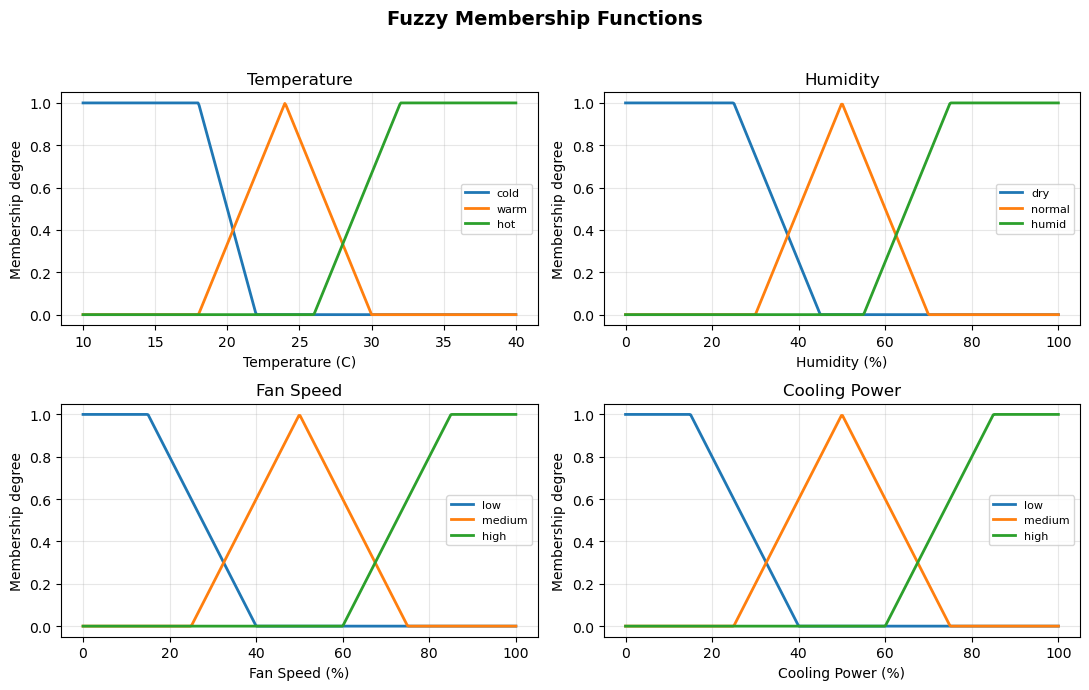

In [9]:
variables = [
    (controller.temperature, "Temperature (C)"),
    (controller.humidity, "Humidity (%)"),
    (controller.fan_speed, "Fan Speed (%)"),
    (controller.cooling_power, "Cooling Power (%)"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (var, xlabel) in zip(axes.flat, variables):
    lo, hi = var.universe
    xs = np.linspace(lo, hi, 400)
    for term, fn in var.sets.items():
        ys = [fn(x) for x in xs]
        ax.plot(xs, ys, label=term, linewidth=2)
    ax.set_title(var.name.replace("_", " ").title())
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Membership degree")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Fuzzy Membership Functions", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(OUTPUT_DIR, "membership_functions.png"), dpi=150)
plt.show()


### 7.2 Control surface (fan speed & cooling power vs. temperature & humidity)

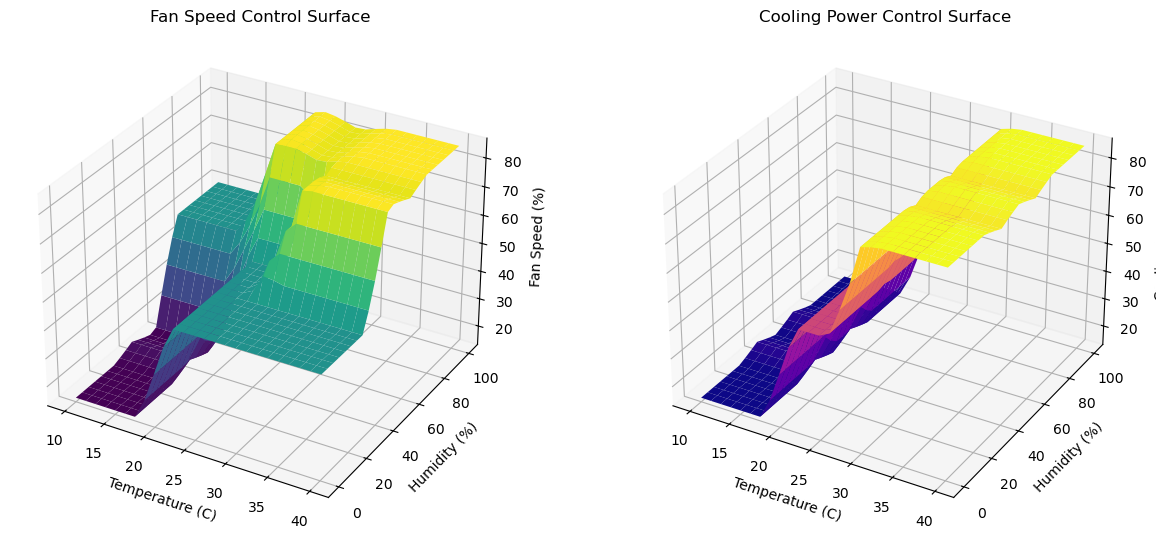

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

temps = np.linspace(10, 40, 25)
hums = np.linspace(0, 100, 25)
T, H = np.meshgrid(temps, hums)
Fan = np.zeros_like(T)
Cool = np.zeros_like(T)
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        r = controller.infer(T[i, j], H[i, j])
        Fan[i, j] = r.fan_speed
        Cool[i, j] = r.cooling_power

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(T, H, Fan, cmap="viridis", edgecolor="none")
ax1.set_xlabel("Temperature (C)"); ax1.set_ylabel("Humidity (%)"); ax1.set_zlabel("Fan Speed (%)")
ax1.set_title("Fan Speed Control Surface")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(T, H, Cool, cmap="plasma", edgecolor="none")
ax2.set_xlabel("Temperature (C)"); ax2.set_ylabel("Humidity (%)"); ax2.set_zlabel("Cooling Power (%)")
ax2.set_title("Cooling Power Control Surface")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "control_surface.png"), dpi=150)
plt.show()


### 7.3 Worked example: aggregated output + centroid

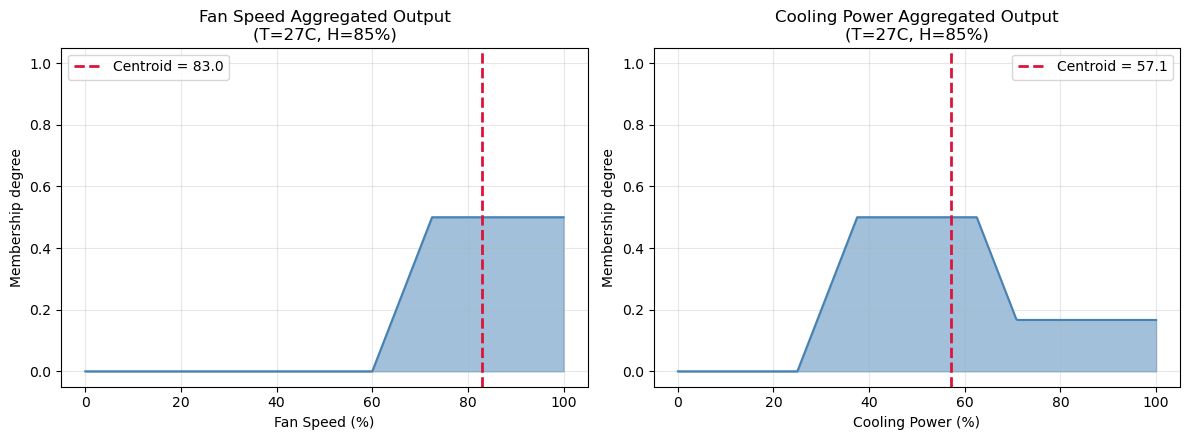

In [11]:
def plot_worked_example(temperature=27, humidity=85):
    result = controller.infer(temperature, humidity)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, points, out_val, title in [
        (axes[0], result.fan_speed_aggregate, result.fan_speed, "Fan Speed"),
        (axes[1], result.cooling_power_aggregate, result.cooling_power, "Cooling Power"),
    ]:
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        ax.fill_between(xs, ys, color="steelblue", alpha=0.5)
        ax.plot(xs, ys, color="steelblue")
        ax.axvline(out_val, color="crimson", linestyle="--", linewidth=2,
                   label=f"Centroid = {out_val:.1f}")
        ax.set_title(f"{title} Aggregated Output\n(T={temperature}C, H={humidity}%)")
        ax.set_xlabel(f"{title} (%)")
        ax.set_ylabel("Membership degree")
        ax.set_ylim(-0.05, 1.05)
        ax.legend()
        ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "worked_example.png"), dpi=150)
    plt.show()
    return result

_ = plot_worked_example(27, 85)


## 8. Interactive Widget Demo

The original project included a Tkinter desktop GUI (`gui.py`). In a notebook, `ipywidgets`
gives the same live-slider experience: move Temperature/Humidity below and watch the outputs
and firing rules update immediately.

> If widgets don't render (e.g. viewing a static export of this notebook), re-run this cell in a
> live Jupyter session with `ipywidgets` installed (`pip install ipywidgets`).


In [13]:
from ipywidgets import interact, FloatSlider

def _demo(temperature=27.0, humidity=60.0):
    result = controller.infer(temperature, humidity)
    print(controller.explain(result, top_n=6))

interact(
    _demo,
    temperature=FloatSlider(min=10, max=40, step=0.5, value=27, description="Temp (C)"),
    humidity=FloatSlider(min=0, max=100, step=1, value=60, description="Humidity (%)"),
);


interactive(children=(FloatSlider(value=27.0, description='Temp (C)', max=40.0, min=10.0, step=0.5), FloatSlid…

## 9. Unit Tests

Adapted from `tests/test_fuzzy_system.py`, run inline with `unittest`.


In [14]:
import unittest

class TestMembershipFunctions(unittest.TestCase):
    def test_triangular_peak(self):
        self.assertAlmostEqual(triangular(50, 25, 50, 75), 1.0)

    def test_triangular_edges_are_zero(self):
        self.assertAlmostEqual(triangular(25, 25, 50, 75), 0.0)
        self.assertAlmostEqual(triangular(75, 25, 50, 75), 0.0)

    def test_trapezoidal_plateau(self):
        self.assertAlmostEqual(trapezoidal(50, 0, 40, 60, 100), 1.0)

    def test_trapezoidal_outside_support(self):
        self.assertAlmostEqual(trapezoidal(-5, 0, 40, 60, 100), 0.0)
        self.assertAlmostEqual(trapezoidal(105, 0, 40, 60, 100), 0.0)


class TestFuzzyACController(unittest.TestCase):
    def setUp(self):
        self.controller = FuzzyACController()

    def test_output_in_valid_range(self):
        for t in range(10, 41, 5):
            for h in range(0, 101, 10):
                result = self.controller.infer(t, h)
                self.assertGreaterEqual(result.fan_speed, 0.0)
                self.assertLessEqual(result.fan_speed, 100.0)

    def test_cold_dry_gives_low_output(self):
        result = self.controller.infer(12, 15)
        self.assertLess(result.fan_speed, 35)
        self.assertLess(result.cooling_power, 35)

    def test_hot_humid_gives_high_output(self):
        result = self.controller.infer(38, 90)
        self.assertGreater(result.fan_speed, 65)
        self.assertGreater(result.cooling_power, 65)

    def test_deterministic_output(self):
        r1 = self.controller.infer(29, 65)
        r2 = self.controller.infer(29, 65)
        self.assertEqual(r1.fan_speed, r2.fan_speed)

suite = unittest.TestLoader().loadTestsFromModule(__import__("__main__"))
unittest.TextTestRunner(verbosity=2).run(suite)


test_cold_dry_gives_low_output (__main__.TestFuzzyACController.test_cold_dry_gives_low_output) ... ok
test_deterministic_output (__main__.TestFuzzyACController.test_deterministic_output) ... ok
test_hot_humid_gives_high_output (__main__.TestFuzzyACController.test_hot_humid_gives_high_output) ... ok
test_output_in_valid_range (__main__.TestFuzzyACController.test_output_in_valid_range) ... ok
test_trapezoidal_outside_support (__main__.TestMembershipFunctions.test_trapezoidal_outside_support) ... ok
test_trapezoidal_plateau (__main__.TestMembershipFunctions.test_trapezoidal_plateau) ... ok
test_triangular_edges_are_zero (__main__.TestMembershipFunctions.test_triangular_edges_are_zero) ... ok
test_triangular_peak (__main__.TestMembershipFunctions.test_triangular_peak) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.154s

OK


<unittest.runner.TextTestResult run=8 errors=0 failures=0>

## Summary

- Implemented a complete Mamdani fuzzy inference pipeline (fuzzification -> rule evaluation ->
  implication -> aggregation -> centroid defuzzification) from scratch.
- Validated with a 10-case test battery and unit tests - all outputs fall within `[0, 100]%` and
  match expected qualitative behavior.
- Visualized membership functions, the full control surface, and a worked defuzzification
  example.
- Replaced the desktop Tkinter GUI with an in-notebook `ipywidgets` interactive demo.
